## Configuration

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial


from lordcapulet.data_structures.databank import DataBank
from botorch.acquisition import UpperConfidenceBound
from botorch.acquisition.objective import ScalarizedPosteriorTransform

from gp_model import create_gp_model, train_gp_model
from acquisition import AnalyticCustomPreference, compute_total_preference_fast
from optimizer import optimize_acquisition, create_bounds_tensor, create_patchwork_guess

# =============================================================================
# CONFIGURATION
# =============================================================================

CONFIG = {
    # Device
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    
    # Data
    # "data_file": "FeO_scan_data_extractor_redone.json",
    "data_file": "UO2_scan_data_extractor_so_n_converted.json",
    "train_ratio": 0.1,  # Fraction of data for training
    
    # Physics Mean Function
    "mean": {
        "type": "VectorizedPhysicsMean",
        # "type": "HubbardUMean",
        "J_prior": {"mean": 0.5, "std": 0.1},
        "U_prior": {"mean": 5.0, "std": 0.2},
    },
    
    # Kernel Configuration
    "kernel": {
        "local": {
            # "matern": {"enabled": True, "nu": 2.5, "outputscale_prior": {"mean": 2, "std": 0.2}},
            "matern": {"enabled": True, "nu": 2.5, "outputscale_prior": {"mean": 0.2, "std": 0.02}},
            # "matern": {"enabled": True, "nu": 2.5, "outputscale_prior": {"mean": 0.002, "std": 0.0000002}},
        },
        "nonlocal": {
            "residual": {"enabled": False, "outputscale_prior": {"mean": 0.05, "std": 0.003}},
        },
        "spin_flip_invariant": True,
    },
    
    # Acquisition Function
    "acquisition": {
        "beta": 1,  # Exploration parameter (0=pure exploitation)
        "use_preference": True,
        "trace_target": 2.7,  # Target electron count
        # "trace_target": 6.3,  # Target electron count
        "trace_sigma": 0.5,  # Increased to allow more variation 
        # "trace_sigma": 1.0,  # Increased to allow more variation
        "use_eigenvalue_preference": True,  # Eigenvalue constraints
        "eigenvalue_k": 20000.0,
        "supergaussian_index": 4,  # Super-Gaussian index for trace preference
    },
    
    # Optimization
    "optimization": {
        "num_candidates": 10,
        "init_strategy": "patchwork",  # "best_train", "patchwork", or None
        "apply_rotation": False,  # Apply random rotations to patchwork guess
        "num_restarts": 40,
        "raw_samples": 128,
    },
}


DEVICE = torch.device(CONFIG["device"])
print(f"Device: {DEVICE}")
print(f"Data: {CONFIG['data_file']}")
print(f"Candidates to generate: {CONFIG['optimization']['num_candidates']}")

Device: cuda
Data: UO2_scan_data_extractor_so_n_converted.json
Candidates to generate: 10


## Data Loading

In [3]:
# Load data
databank = DataBank.from_json(CONFIG["data_file"], only_converged=True)
atoms = databank.atom_ids

# Prepare tensors
x_data = databank.to_pytorch(atom_ids=atoms, spins=['up', 'down'], include_energies=False, device=DEVICE)
energies = torch.tensor([rec['energy'] for rec in databank._records], dtype=torch.float32, device=DEVICE)

# Train/test split
num_train = int(len(x_data) * CONFIG["train_ratio"])
perm = torch.randperm(len(x_data))
x_train, y_train = x_data[perm[:num_train]], energies[perm[:num_train]]
x_test, y_test = x_data[perm[num_train:]], energies[perm[num_train:]]

# Create bounds
bounds = create_bounds_tensor(databank, atoms, DEVICE)

print(f"Loaded {len(databank)} calculations")
print(f"Atoms: {atoms}")
print(f"Training: {len(x_train)} | Test: {len(x_test)}")
print(f"Energy range: [{energies.min():.2f}, {energies.max():.2f}] eV")



Loaded 720 calculations
Atoms: ['1', '2', '3', '4']
Training: 72 | Test: 648
Energy range: [-59738.60, -59735.87] eV


## Model Training

In [4]:
# Create and train GP model
model = create_gp_model(
    train_X=x_train,
    train_Y=y_train.unsqueeze(-1),
    databank=databank,
    atom_ids=atoms,
    mean_config=CONFIG["mean"],
    kernel_config=CONFIG["kernel"],
    device=DEVICE
)

model = train_gp_model(model, x_train, y_train.unsqueeze(-1), {"method": "fit_gpytorch_mll"})

# Evaluate on test set
from gp_model import evaluate_model
results = evaluate_model(model, x_test, y_test)

print(f"\nModel Performance:")
print(f"  R² = {results['r2']:.4f}")
print(f"  RMSE = {results['rmse']:.4f} eV")

if hasattr(model.mean_module, 'U'):
    print(f"\n Learned Hubbard parameter")
    print(f"  U = {model.mean_module.U.item():.4f}")
    print(f"  Offset = {model.mean_module.constant.item():.4f} eV")

if hasattr(model.mean_module, 'J'):
    print(f"\nLearned Hund Parameter:")
    print(f"  J = {model.mean_module.J.item():.4f}")

from gp_model import print_kernel_diagnostics
print_kernel_diagnostics(model)

/home/carta_a/Documents/Local_calculations/aiida-LordCapulet/lordcapulet/functions/proposal_modes/Bayesian/gp_model.py:62: InputDataWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/meta-pytorch/botorch/discussions/1444
  model = SingleTaskGP(



Model Performance:
  R² = 0.9306
  RMSE = 0.1395 eV

 Learned Hubbard parameter
  U = 3.8781
  Offset = -4.1169 eV

Learned Hund Parameter:
  J = 0.5218

KERNEL TYPE                    | VARIANCE (Outputscale)   
LOCAL: Texture (Matern)        | 0.19176                  
LOCAL: Texture (Matern)        | 0.18862                  
LOCAL: Texture (Matern)        | 0.18991                  
LOCAL: Texture (Matern)        | 0.18893                  



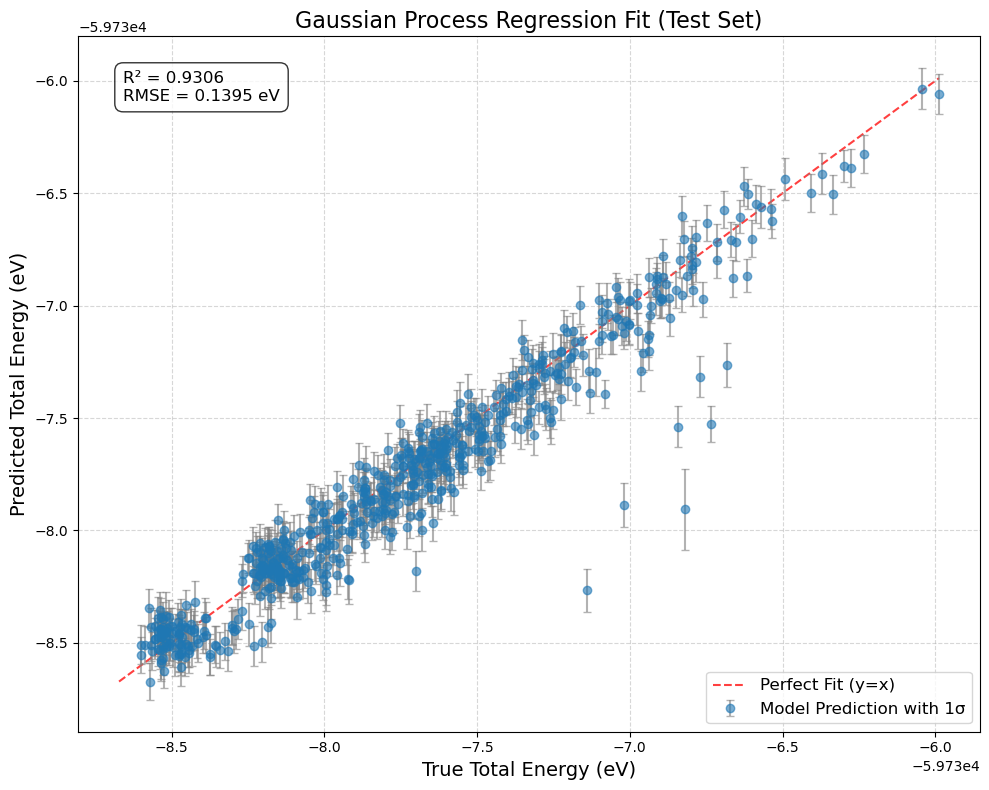

In [5]:

# Visualize predictions vs actual
plt.figure(figsize=(10, 8))

# Plot diagonal line
lims = [
    min(results['y_true'].min(), results['y_pred'].min()),
    max(results['y_true'].max(), results['y_pred'].max()),
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=1, label="Perfect Fit (y=x)")

# Scatter with error bars
plt.errorbar(
    results['y_true'], 
    results['y_pred'], 
    yerr=results['y_std'],
    fmt='o', 
    alpha=0.6, 
    ecolor='gray', 
    capsize=3,
    zorder=2,
    label="Model Prediction with 1σ"
)

plt.xlabel("True Total Energy (eV)", fontsize=14)
plt.ylabel("Predicted Total Energy (eV)", fontsize=14)
plt.title("Gaussian Process Regression Fit (Test Set)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Add metrics to plot
text_str = f"R² = {results['r2']:.4f}\nRMSE = {results['rmse']:.4f} eV"
plt.text(
    0.05, 0.95, text_str,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

## Generate Candidates

In [10]:
from botorch.optim import optimize_acqf
import warnings

# Create acquisition function
base_acqf = UpperConfidenceBound(
    model=model,
    beta=CONFIG["acquisition"]["beta"],
    posterior_transform=ScalarizedPosteriorTransform(weights=torch.tensor([-1.0])),
    maximize=True
)

if CONFIG["acquisition"]["use_preference"]:
    pref_func = partial(
        compute_total_preference_fast,
        databank=databank,
        atom_ids=atoms,
        trace_target=CONFIG["acquisition"]["trace_target"],
        trace_sigma=CONFIG["acquisition"]["trace_sigma"],
        use_eigenvalue_preference=True,#CONFIG["acquisition"]["use_eigenvalue_preference"],
        eig_k=CONFIG["acquisition"]["eigenvalue_k"],
        supergaussian_index=CONFIG["acquisition"]["supergaussian_index"],
    )
    acqf = AnalyticCustomPreference(model=model, base_acqf=base_acqf,
                                     compute_preference_func=pref_func)
else:
    acqf = base_acqf

# acqf = base_acqf

# Generate candidates
print(f"\nGenerating {CONFIG['optimization']['num_candidates']} candidates...")

# Strategy: Generate multiple physics-informed initial guesses
num_physics_guesses = CONFIG['optimization']['num_candidates'] 
num_restarts_actual = num_physics_guesses  # Match restarts to number of good guesses



### optimization based candidate generation

# print(f"Using {num_physics_guesses} physics-informed initial guesses with {num_restarts_actual} restarts per candidate\n")

# candidates_list = []
# acqf_values_list = []

# for i in range(CONFIG['optimization']['num_candidates']):
#     # Generate multiple diverse physics-informed initial guesses
#     initial_guesses = []
    
#     if CONFIG['optimization']['init_strategy'] == "best_train":
#         # Use top-k training points
#         sorted_idx = torch.argsort(y_train)
#         for k in range(min(num_physics_guesses, len(y_train))):
#             guess = x_train[sorted_idx[k]].unsqueeze(0).unsqueeze(0)
#             initial_guesses.append(guess)
    
#     elif CONFIG['optimization']['init_strategy'] == "patchwork":
#         # Generate multiple patchwork combinations
#         for _ in range(num_physics_guesses):
#             guess = create_patchwork_guess(
#                 databank, x_train, atoms, DEVICE,
#                 # apply_rotation=CONFIG['optimization']['apply_rotation']
#                 apply_rotation=True
#             )
#             initial_guesses.append(guess)
    
#     # Stack all guesses into batch [num_guesses, 1, num_features]
#     if initial_guesses:
#         batch_initial_conditions = torch.cat(initial_guesses, dim=0)
#     else:
#         batch_initial_conditions = None
    
#     # Optimize with physics-informed restarts
#     candidate_batch, acqf_value_batch = optimize_acqf(
#         acq_function=acqf,
#         bounds=bounds,
#         q=1,
#         num_restarts=num_restarts_actual,
#         raw_samples=128,   
#         batch_initial_conditions=batch_initial_conditions,
#         return_best_only=False,
#     )

#     # The physics-informed constraints of the acquisition function are actually so tight
#     # that basically no gradient update is made, this would be a good candidate for boltzmann sampling
#     # or alternatively one should use the SO(N) representation for the symmetric matrices 

#     best_acqf_idx = torch.argmax(acqf_value_batch)
#     candidate = candidate_batch[best_acqf_idx].unsqueeze(0)
#     acqf_value = acqf_value_batch[best_acqf_idx]

#     initial_acquisition_value = acqf(batch_initial_conditions[best_acqf_idx].unsqueeze(0)).item() if batch_initial_conditions is not None else float('nan')

    
#     candidates_list.append(candidate)
#     acqf_values_list.append(acqf_value.item())
#     print(f"  Candidate {i+1}/{CONFIG['optimization']['num_candidates']}: acqf = {acqf_value.item():.8f} from initial acqf = {initial_acquisition_value:.8f}")

# candidates = torch.cat(candidates_list, dim=0)
# print(f"\n✓ Generated {len(candidates_list)} candidates")


### Boltzmann sampling based candidate generation

# alternatively generate a set of guesses via patchwork with rotations and do 
# boltzmann sampling on the acquisition function to select among them

from botorch.generation.sampling import BoltzmannSampling
import time
from importlib import reload
import acquisition
import optimizer
reload(acquisition)
reload(optimizer)

BatchedAcqFunc = acquisition.BatchedAcqFunc
create_patchwork_guess = optimizer.create_patchwork_guess


ensamble_size = 50000


acqf = base_acqf
batched_acqf = BatchedAcqFunc(acqf, batch_size=100)

# get a tensor of num_physics_guesses candidates

candidate_list = torch.empty((num_physics_guesses, x_train.shape[1]), device=DEVICE)
ensamble_batch = torch.empty((ensamble_size, x_train.shape[1]), device=DEVICE)

# time ensamble generation


start_ensamble = time.time()
for iguess in range(ensamble_size):
    guess = create_patchwork_guess(
                databank, x_train, atoms, DEVICE,
                apply_rotation=False,
                rotation_prob=0.2,
                rotation_type='Mixed'
            )
    ensamble_batch[iguess,:] = guess.squeeze(0)
end_ensamble = time.time()
print(f"Generated ensamble of {ensamble_size} candidates in {end_ensamble - start_ensamble:.2f} seconds")

sampler = BoltzmannSampling(acq_func=batched_acqf, eta =30, replacement=False) # high eta, low T
start_sampling = time.time()

with torch.no_grad():
    candidates = sampler(ensamble_batch, num_samples = num_physics_guesses)

end_sampling = time.time()
print(f"Sampled {num_physics_guesses} candidates in {end_sampling - start_sampling:.2f} seconds")

candidates_list = [candidate.unsqueeze(0) for candidate in candidates]

acqf_values_list = [acqf(candidate).item() for candidate in candidates_list]





Generating 10 candidates...
Generated ensamble of 50000 candidates in 55.02 seconds
Sampled 10 candidates in 5.26 seconds


In [11]:
# test acquisition on initial guess
from importlib import reload
import lordcapulet.functions.proposal_modes.Bayesian.acquisition as acquisition

reload(acquisition)



result_cpu = acquisition.compute_total_preference_fast(
    candidates[0].unsqueeze(0),
    databank=databank,
    atom_ids=atoms,
    trace_target=CONFIG["acquisition"]["trace_target"],
    trace_sigma=CONFIG["acquisition"]["trace_sigma"],
    use_eigenvalue_preference=CONFIG["acquisition"]["use_eigenvalue_preference"],
    eig_k=CONFIG["acquisition"]["eigenvalue_k"]
)

print(f"Preference score (CPU): {result_cpu}")


Preference score (CPU): tensor([0.9968], device='cuda:0')


## Summary of Candidates

In [12]:
# Summary table
print("\n" + "="*80)
print("CANDIDATE SUMMARY")
print("="*80)
print(f"{'#':<4} {'Acqf':<12} {'Energy (eV)':<20} {'Uncertainty':<12}")
print("-"*80)

with torch.no_grad():
    for i, (cand, acqf_val) in enumerate(zip(candidates_list, acqf_values_list)):
        posterior = model.posterior(cand)
        mean_energy = posterior.mean.item()
        std_energy = posterior.variance.sqrt().item()
        print(f"{i:<4} {acqf_val:<12.4f} {mean_energy:<12.4f} ± {std_energy:<12.4f}")

print("="*80)
best_idx = np.argmax(acqf_values_list)
print(f"Best acquisition: Candidate {best_idx + 1}")


CANDIDATE SUMMARY
#    Acqf         Energy (eV)          Uncertainty 
--------------------------------------------------------------------------------
0    59738.7344   -59738.6445  ± 0.0902      
1    59738.7695   -59738.6875  ± 0.0814      
2    59738.6953   -59738.6055  ± 0.0886      
3    59738.7695   -59738.6875  ± 0.0820      
4    59738.8008   -59738.7148  ± 0.0856      
5    59738.7305   -59738.6406  ± 0.0906      
6    59738.7578   -59738.6797  ± 0.0763      
7    59738.5977   -59738.5000  ± 0.0977      
8    59738.6602   -59738.5820  ± 0.0796      
9    59738.7422   -59738.6484  ± 0.0953      
Best acquisition: Candidate 5


## Analyze Specific Candidate


=== Candidate 5 ===
Acquisition: 59738.8008
Energy: -59738.7148 ± 0.0856 eV

1:
  Trace: 2.641
  Eigenvalues (up): [0.035 0.037 0.037 0.039 0.044 0.047 0.116]
  Eigenvalues (down): [0.04  0.044 0.044 0.051 0.142 0.982 0.983]


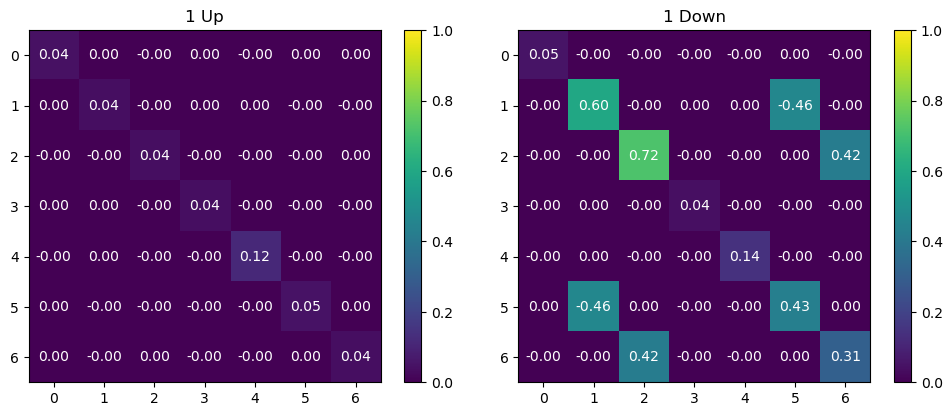


2:
  Trace: 2.641
  Eigenvalues (up): [0.041 0.045 0.047 0.056 0.145 0.981 0.982]
  Eigenvalues (down): [0.034 0.035 0.037 0.039 0.043 0.043 0.113]


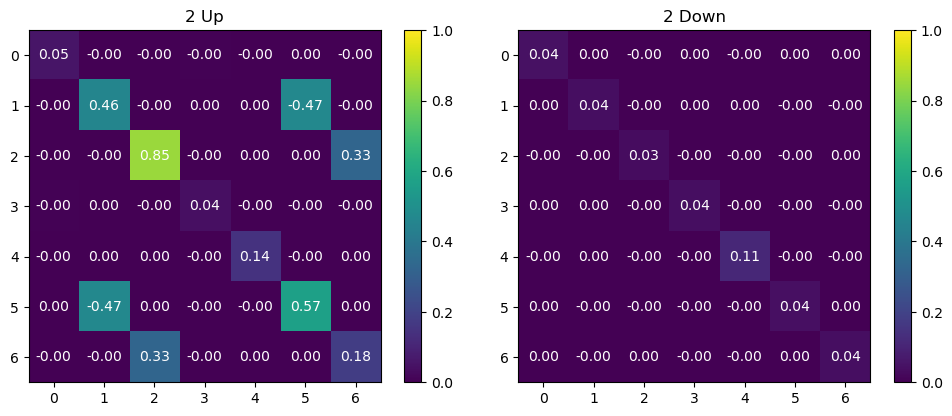


3:
  Trace: 2.644
  Eigenvalues (up): [0.042 0.049 0.049 0.052 0.141 0.98  0.988]
  Eigenvalues (down): [0.033 0.036 0.036 0.041 0.042 0.043 0.112]


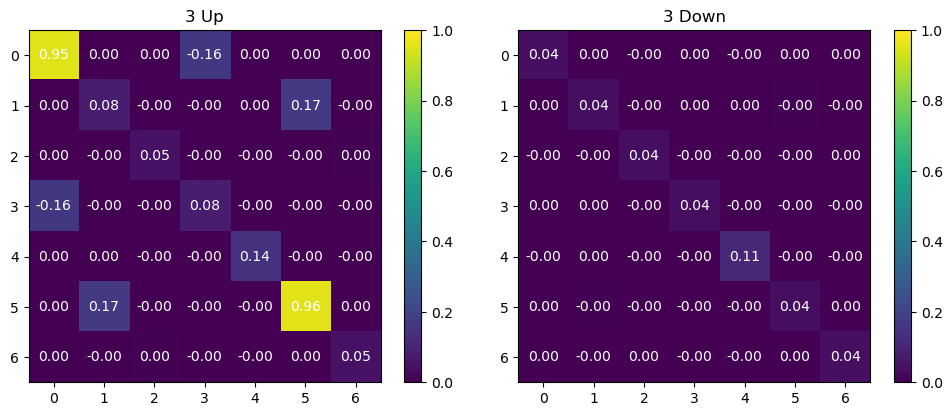


4:
  Trace: 2.653
  Eigenvalues (up): [0.035 0.036 0.038 0.043 0.046 0.051 0.115]
  Eigenvalues (down): [0.04  0.043 0.046 0.052 0.138 0.982 0.988]


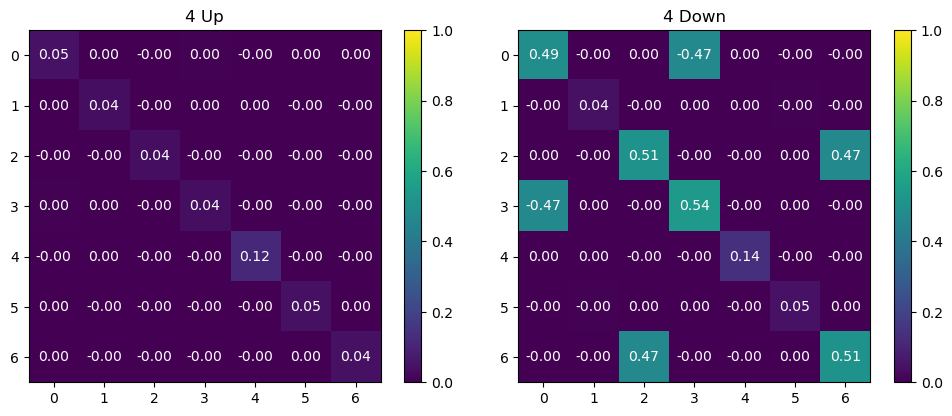

In [13]:
# Select candidate to analyze
CANDIDATE_INDEX = best_idx   # Change this to analyze different candidates

candidate = candidates_list[CANDIDATE_INDEX]
matrices_candidate = databank.from_pytorch(
    candidate[0].detach(), 
    atom_ids=atoms, 
    spins=['up', 'down']
)[0]

print(f"\n=== Candidate {CANDIDATE_INDEX + 1} ===")
print(f"Acquisition: {acqf_values_list[CANDIDATE_INDEX]:.4f}")

# compute minor multiplier for this candidate

from acquisition import compute_minor_preference_offdiag_only



with torch.no_grad():
    posterior = model.posterior(candidate)
    print(f"Energy: {posterior.mean.item():.4f} ± {posterior.variance.sqrt().item():.4f} eV")

# Display occupation matrices
for atom_id in atoms:
    up_mat = np.array(matrices_candidate.get_occupation_matrix(atom_id, 'up'))
    down_mat = np.array(matrices_candidate.get_occupation_matrix(atom_id, 'down'))

    print(f"\n{atom_id}:")
    print(f"  Trace: {np.trace(up_mat) + np.trace(down_mat):.3f}")
    print(f"  Eigenvalues (up): {np.round(np.linalg.eigvalsh(up_mat), 3)}")
    print(f"  Eigenvalues (down): {np.round(np.linalg.eigvalsh(down_mat), 3)}")
    
    # Visualize
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    
    for idx, (mat, title) in enumerate([(up_mat, 'Up'), (down_mat, 'Down')]):
        im = axs[idx].imshow(np.abs(mat), cmap='viridis', vmin=0, vmax=1)
        axs[idx].set_title(f'{atom_id} {title}')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                axs[idx].text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', color='w')
        fig.colorbar(im, ax=axs[idx])
    
    plt.tight_layout()
    plt.show()

## Novelty Analysis


Novelty Metrics:
  Min distance to training: 2.681724
  Mean distance: 3.393904
  Median distance: 3.445681


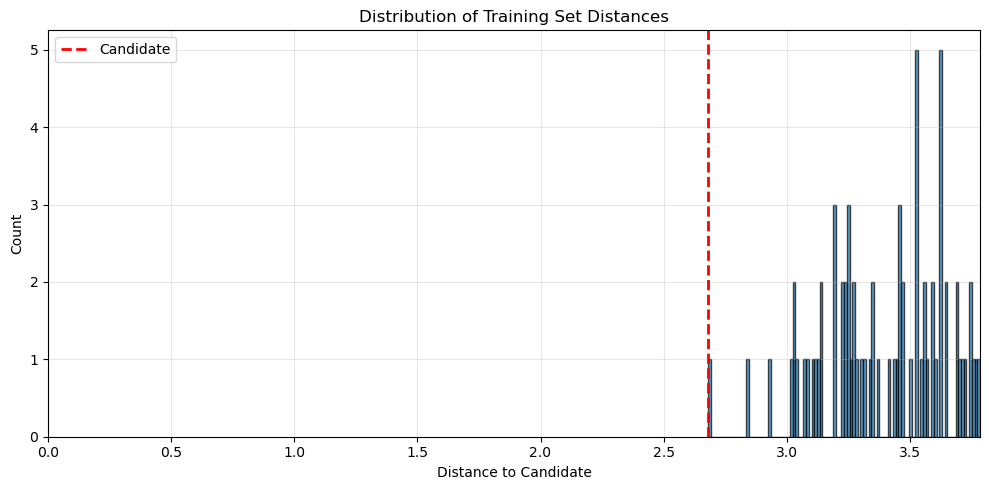

In [14]:
# Compute distances to training set
train_indices = perm[:num_train].cpu().numpy()
train_databank = databank[train_indices]

distances = train_databank.compute_distances(
    reference=matrices_candidate,
    atom_label=None,
    spins=['up', 'down']
)

print(f"\nNovelty Metrics:")
print(f"  Min distance to training: {distances.min():.6f}")
print(f"  Mean distance: {distances.mean():.6f}")
print(f"  Median distance: {np.median(distances):.6f}")

# Visualize
plt.figure(figsize=(10, 5))
plt.hist(distances, bins=100, alpha=0.7, edgecolor='black')
plt.axvline(distances.min(), color='red', linestyle='--', linewidth=2, label='Candidate')
plt.xlim(0, distances.max())
plt.xlabel("Distance to Candidate")
plt.ylabel("Count")
plt.title("Distribution of Training Set Distances")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Closest training example index: 407 with distance 1.199494

=== Closest Training Example vs Candidate ===

1:
  Closest Trace: 6.238
  Candidate Trace: 6.237


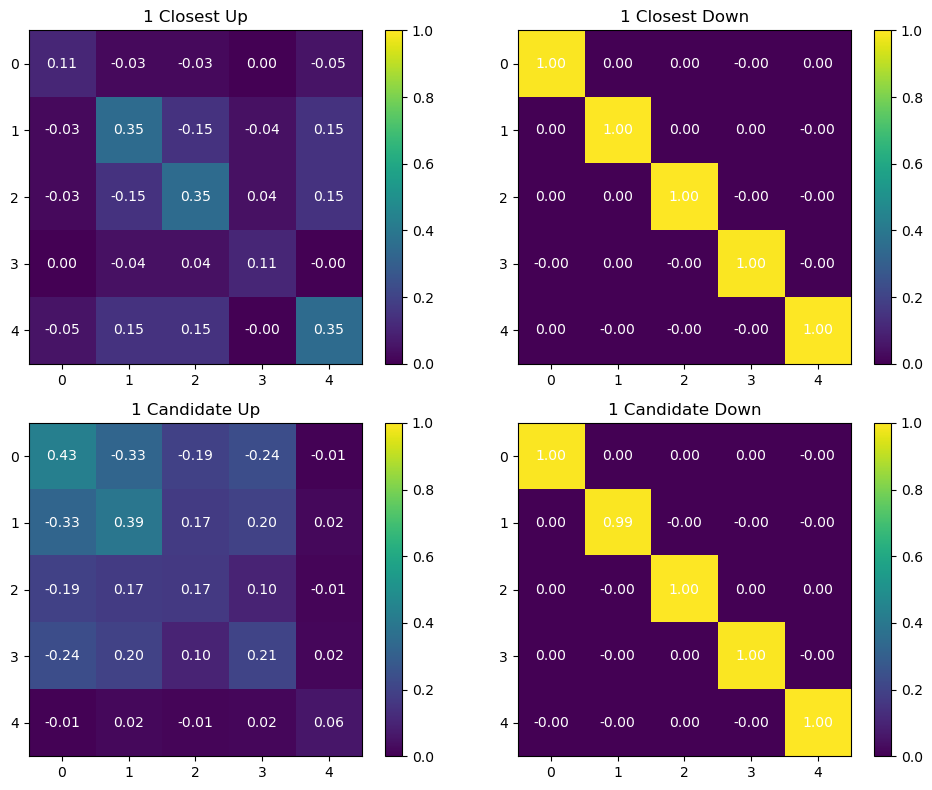


2:
  Closest Trace: 6.238
  Candidate Trace: 6.217


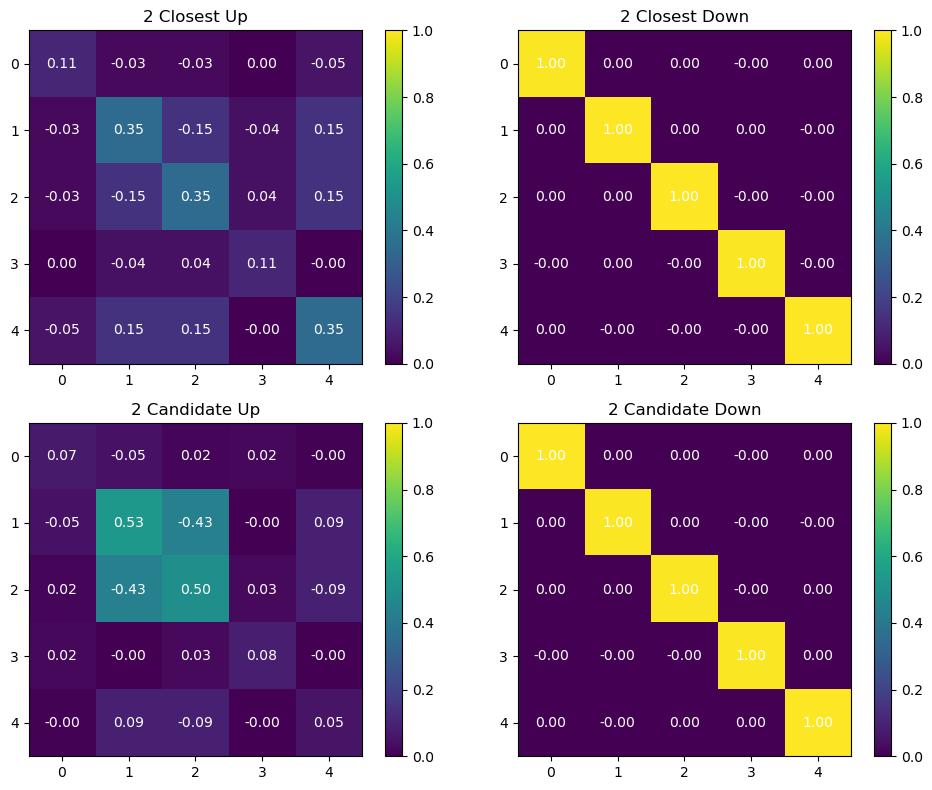

In [88]:
# plot the closest training example together with the candidate
closest_idx = np.argmin(distances)
closest_example = train_databank.get_occ_data(closest_idx)

print(f"\nClosest training example index: {train_indices[closest_idx]} with distance {distances.min():.6f}")
print(f"\n=== Closest Training Example vs Candidate ===")
for atom_id in atoms:
    up_mat_closest = np.array(closest_example.get_occupation_matrix(atom_id, 'up'))
    down_mat_closest = np.array(closest_example.get_occupation_matrix(atom_id, 'down'))
    up_mat_candidate = np.array(matrices_candidate.get_occupation_matrix(atom_id, 'up'))
    down_mat_candidate = np.array(matrices_candidate.get_occupation_matrix(atom_id, 'down'))

    print(f"\n{atom_id}:")
    print(f"  Closest Trace: {np.trace(up_mat_closest) + np.trace(down_mat_closest):.3f}")
    print(f"  Candidate Trace: {np.trace(up_mat_candidate) + np.trace(down_mat_candidate):.3f}")
 
    # Visualize
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))  

    for idx, (mat, title) in enumerate([(up_mat_closest, 'Closest Up'), (down_mat_closest, 'Closest Down'),
                                       (up_mat_candidate, 'Candidate Up'), (down_mat_candidate, 'Candidate Down')]):
        ax = axs[idx//2, idx%2]
        im = ax.imshow(np.abs(mat), cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'{atom_id} {title}')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', color='w')
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()  